Data (X, y)
   ↓ preprocess_y
SurrogateTrainer.fit
   ↓
Grid (compute_bounds → create_nd_grid → filter_grid)
   ↓
trainer.predict → mean
pairwise_distances → std
   ↓
compute_acquisition (PI/EI/UCB, xi/kappa)
   ↓
argmax → next_query, score
   ↓
log_query_candidate
   ↓
find_best_candidate → best

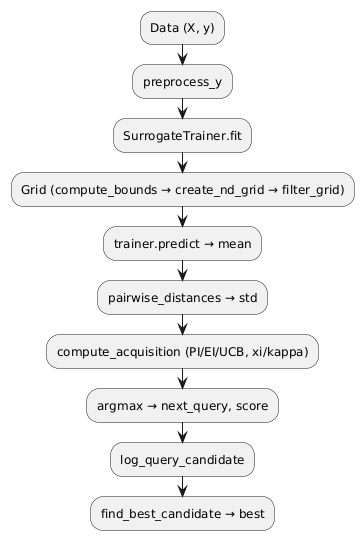

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Raw Inputs
: [[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]]
Raw Outputs
: [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837]
    compound-1  compound-2  compound-3  trans-side-effect  source
18    0.448900    0.470829    0.414315          -0.020404  week-4
16    0.303031    0.242424    0.474748          -0.030680  week-2
3     0.492581    0.611593    0.340176          -0

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_31412/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


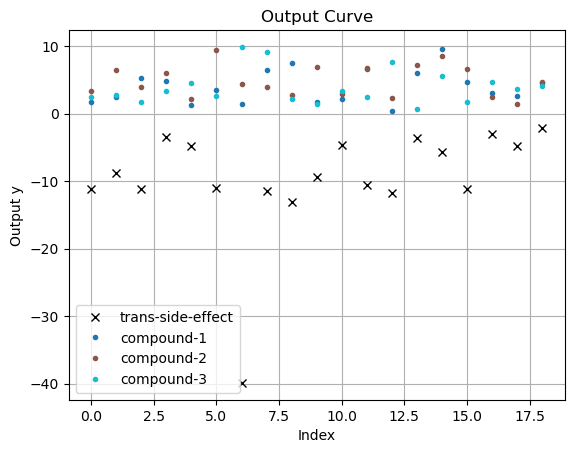

In [2]:
#Process data
%run data_handler.ipynb

In [3]:
#row_lowest_A = df_sorted.loc[df["radiation-reading"].idxmin()]
#print(row_lowest_A)
#df_sorted.drop(df["radiation-reading"].idxmin(), inplace=True)
# Preview
#print(df_sorted)
#plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=1000, nan_marker='o')


In [4]:
X = inputs
y = outputs

In [5]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []


In [6]:
def sweep_hyperparameters_NNtrain(X, y,
                                  xi_values=[0.01, 0.1, 0.3],
                                  kappa_values=[1.0, 2.0, 3.0],
                                  grid_sizes=[400],
                                  methods=['PI', 'EI', 'UCB'],
                                  apply_scaling=False,
                                  filter_mode='gp'):
    """
    Sweep hyperparameters for query selection using a trained NN surrogate.
    Applies Bayesian optimisation acquisition functions (PI, EI, UCB).
    """
    global query_results
    query_results = []

    # Step 1: preprocess targets
    y_proc = preprocess_y(y, apply_scaling=apply_scaling)

    # Step 2: train NN surrogate once
    trainer = SurrogateTrainer(input_dim=X.shape[1], lr=1e-3, epochs=500)
    print("Epoch ", trainer.epochs)
    history = trainer.fit(X, y_proc, log_weights=True)
    # Plot loss curve
    plot_loss_curve(history)

    # Plot weight evolution (first layer mean)
    plot_weight_evolution(history, layer_name="model.0.weight", stat="mean")    

    # Step 3: loop over grid sizes
    for grid_size in grid_sizes:
        bounds = compute_bounds(X, margin=0.1)
        X_grid_full = create_nd_grid(bounds, grid_size)
        X_grid_filtered = filter_grid(X, y_proc, X_grid_full, filter_mode=filter_mode)

        if X_grid_filtered.shape[0] == 0:
            print(f"⚠️ Skipping grid_size={grid_size}, filter removed all points")
            continue

        # Step 4: predict surrogate outputs once per grid
        mean = trainer.predict(X_grid_filtered)
        
        # Step 5: uncertainty heuristic (distance to nearest training point)
        dist = pairwise_distances(X_grid_filtered, X)
        std = np.min(dist, axis=1)

        # Step 6: sweep acquisition hyperparameters
        for method in methods:
            if method in ['PI', 'EI']:
                for xi in xi_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, xi=xi)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, xi, next_query, score)

            elif method == 'UCB':
                for kappa in kappa_values:
                    acq_map = compute_acquisition(method, mean, std, y_proc, kappa=kappa)
                    best_index = np.argmax(acq_map)
                    next_query = X_grid_filtered[best_index]
                    score = acq_map[best_index]
                    log_query_candidate(method, kappa, next_query, score)

    if not query_results:
        raise RuntimeError("No valid configurations found during sweep.")

    best = find_best_candidate(query_results)
    return X_grid_filtered, mean, bounds, best, query_results

Applying standard scaling to y.
Epoch  500
Epoch 1/500, Loss: 1.087238
Epoch 50/500, Loss: 0.296921
Epoch 100/500, Loss: 0.039690
Epoch 150/500, Loss: 0.016868
Epoch 200/500, Loss: 0.006958
Epoch 250/500, Loss: 0.001865
Epoch 300/500, Loss: 0.000241
Epoch 350/500, Loss: 0.000017
Epoch 400/500, Loss: 0.000001
Epoch 450/500, Loss: 0.000000
Epoch 500/500, Loss: 0.000000


/Users/ajay.amrite/Documents/AI Course/Anaconda Files/Module - 12/Black-Box functions/utils/SurrogateNN.py:81: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403226260/work/aten/src/ATen/native/ReduceOps.cpp:1760.)
  "std": param.data.std().item()


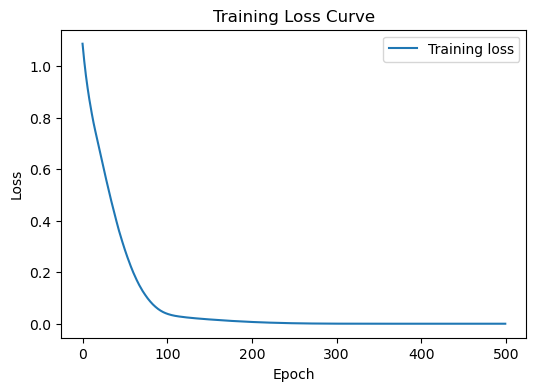

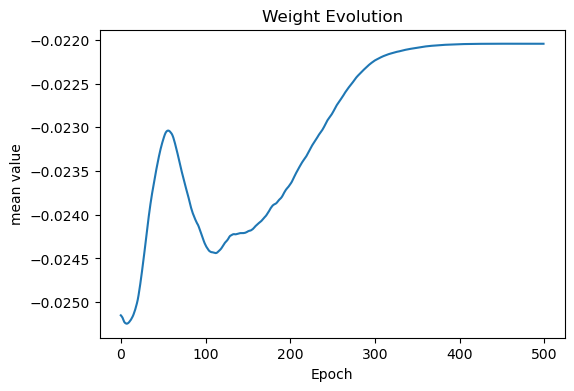

Computing bounds with margin 0.1.
Bounds per feature: [(-0.05319105027750262, 1.0659948489488087), (0.03853199999999998, 1.0413598305723257), (-0.03391135850465135, 1.090881866558951)]
Creating 400^(3) grid.
Grid shape: (64000000, 3)
Filtering grid using mode: median
Grid shape before filtering: (64000000, 3)
Filtered 16598973 candidates near decision boundary (|margin| < 0.2)
Excluded 47401027 candidates from consideration
Final grid shape: (16598973, 3)
Filtered grid shape: (16598973, 3)
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: PI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: EI
Computing acquisition for method: UCB
Computing acquisition for method: UCB
Computing acquisition for method: UCB
Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([ 0.76866727,  1.04135983, -0.03391136]), 'score': 0.9042297451805361, 'dim'

In [7]:
X_grid_filtered, mean, bounds, best, query_results = sweep_hyperparameters_NNtrain(X, y, apply_scaling=True, filter_mode='median')

/opt/anaconda3/envs/tf-macos/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


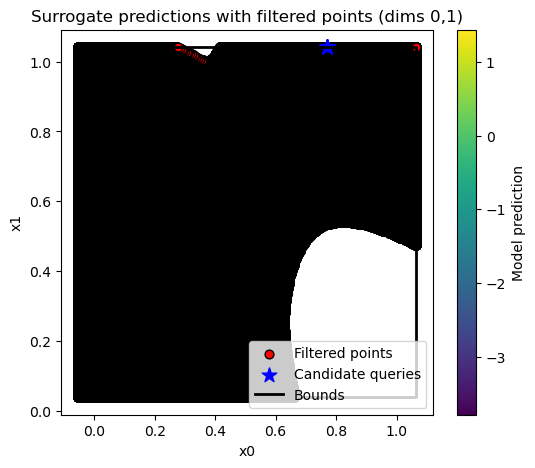

In [8]:
candidates, labels = extract_candidates_and_labels(query_results, include_score=True)

plot_surrogate_generic(X_grid_filtered, mean, 
                       X_filtered=X_grid_filtered, bounds=bounds, candidates=candidates, candidate_labels=None,
                       title="Surrogate predictions with filtered points")


In [9]:
print("Best Hyperparameter Configuration:")
print(best)

Best Hyperparameter Configuration:
{'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([ 0.77147224,  1.04135983, -0.03391136]), 'score': 2.5616208068795117, 'dim': 3}


In [10]:
#add points to dataframe
#print(df)
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    compound-1  compound-2  compound-3  trans-side-effect  source
18    0.448900    0.470829    0.414315          -0.020404  week-4
16    0.303031    0.242424    0.474748          -0.030680  week-2
3     0.492581    0.611593    0.340176          -0.034835    file
13    0.600097    0.725136    0.066089          -0.036378    file
10    0.220549    0.297825    0.343555          -0.046947    file
4     0.134622    0.219917    0.458206          -0.048008    file
17    0.263346    0.138532    0.363743          -0.048179  week-3
14    0.965995    0.861120    0.566829          -0.056758    file
1     0.242114    0.644074    0.272433          -0.087963    file
9     0.170477    0.697032    0.149169          -0.094190    file
11    0.666014    0.671985    0.246295          -0.105965    file
5     0.345523    0.941360    0.269363          -0.110621    file
15    0.464647    0.666667    0.171718          -0.111186  week-1
2     0.534906    0.398501    0.173389          -0.111415    file
0     0.17

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_31412/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


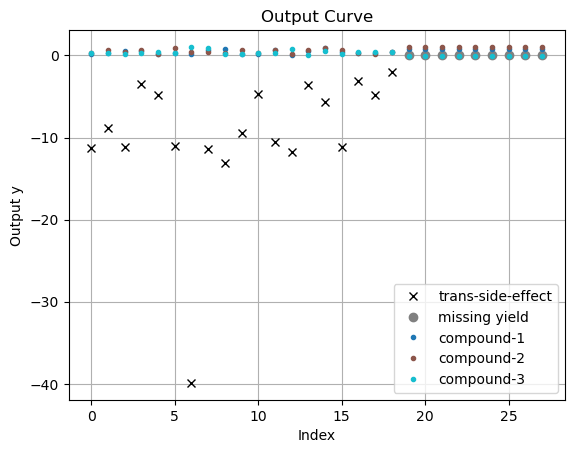

In [11]:
plot_output_points(df_sorted, scale_factor=1.0, yield_scale_factor=100.0, nan_marker='o')